# Predicting Survival of an Individual on the Titanic 🚢

<img src="https://media.vogue.fr/photos/5faac06d39c5194ff9752ec9/2:3/w_1920,c_limit/076_CHL_126884.jpg" width="200">

This tutorial is based on data and the example challenge from the Kaggle community on Titanic data.

Based on the list of Titanic passengers and whether they survived or not, the goal is to predict the chance of survival of an individual based on their name, age, sex, family situation, economic status...

This notebook is inspired by https://www.kaggle.com/mukultiwari/titanic-top-14-with-random-forest

In [2]:
import pandas as pd ; import numpy as np
import matplotlib.pyplot as plt
import multiprocessing
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
import pathlib
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
import time
import os
%matplotlib inline
#import warnings
#warnings.filterwarnings('ignore')

## Data

We will use the `pandas` library to read the data. The dataset from Kaggle has been placed here:

* `train.csv` contains the training data, that is, the variables describing individuals and whether they survived or not;
* `test.csv` contains only the description of individuals for whom we need to predict the chances of survival.

In [3]:
#os.chdir('/home/coder/work/ensae-reproductibilite-application')

TrainingData = pd.read_csv('train.csv')
TrainingData.head()

,Unnamed: 0,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,417,418.0,2.0,"Silven, Miss. Lyyli Karoliina",female,18.0,0.0,2.0,250652,13.0000,NaN,S,NaN
1,490,491.0,3.0,"Hagland, Mr. Konrad Mathias Reiersen",male,NaN,1.0,0.0,65304,19.9667,NaN,S,NaN
2,17,18.0,2.0,"Williams, Mr. Charles Eugene",male,NaN,0.0,0.0,244373,13.0000,NaN,S,NaN
3,771,772.0,3.0,"Jensen, Mr. Niels Peder",male,48.0,0.0,0.0,350047,7.8542,NaN,S,NaN
4,316,317.0,2.0,"Kantor, Mrs. Sinai (Miriam Sternin)",female,24.0,1.0,0.0,244367,26.0000,NaN,S,NaN


In [4]:
TrainingData['Ticket'].str.split("/").str.len()

0       1.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
1597    NaN
1598    NaN
1599    NaN
1600    NaN
1601    NaN
Name: Ticket, Length: 1602, dtype: float64

In [5]:
TrainingData['Name'].str.split(",").str.len()

0       2.0
1       2.0
2       2.0
3       2.0
4       2.0
       ... 
1597    NaN
1598    NaN
1599    NaN
1600    NaN
1601    NaN
Name: Name, Length: 1602, dtype: float64

With the `.info` method, we could verify that our _dataset_ has:

* 7 numeric variables: `PassengerId, Survived, Pclass, Age, SibSp, Parch, Fare`
    * `PassengerId` which is the passenger identifier in the dataset
    * `Survived` which is the variable to predict, the _"target"_ variable
    * `PClass` which is an indicator of socio-economic status
    * `SibSp` and `Parch` which help determine family status (spouse, mother, daughter...)
    * `Fare` which is a price.
* 5 non-numeric variables: `Name, Sex, Ticket` an identifier, `Cabin` a cabin identifier, `Embarked` the port of embarkation (_C = Cherbourg, Q = Queenstown, S = Southampton_)

In [6]:
n_trees = 20
max_depth =None
max_features='sqrt'

## Missing Values

In [7]:
TrainingData.isnull().sum()

Unnamed: 0        0
PassengerId     801
Pclass          801
Name            801
Sex             801
Age             961
SibSp           801
Parch           801
Ticket          801
Fare            801
Cabin          1416
Embarked        803
Survived        801
dtype: int64

As is generally the case in machine learning, we will need to handle these missing values by imputing values:
* in the train dataset (177 missing Age values, 687 missing Cabin values, 2 missing Embarked values)
* in the test dataset (86 missing Age values, 327 missing Cabin values, 1 missing Fare value)

## Some Exploration and Feature Engineering

Before training a model, there is generally an exploratory phase of the dataset, which we will reduce here to the minimum.
There is also, depending on the context, feature engineering which is probably one of the most complex components of machine learning. It consists, depending on the context and the problem, of creating variables that make sense to help solve our problem.

Here, we can do an example naturally on the individual's name by instinctively extracting the title from the names of individuals, but this can be much less natural depending on the problems or even completely state-of-the-art if we take the example of image modeling for machine learning where it is, for example, a matter of proposing values weighted by subdivision of parts of an image.

### Socio-economic Status

A categorical variable that gives an idea of the socio-economic class of the person, with an example using seaborn for visualization https://seaborn.pydata.org/

Clearly, each class didn't have the same chance of survival, isn't that right Jack?

In [9]:
import seaborn as sns

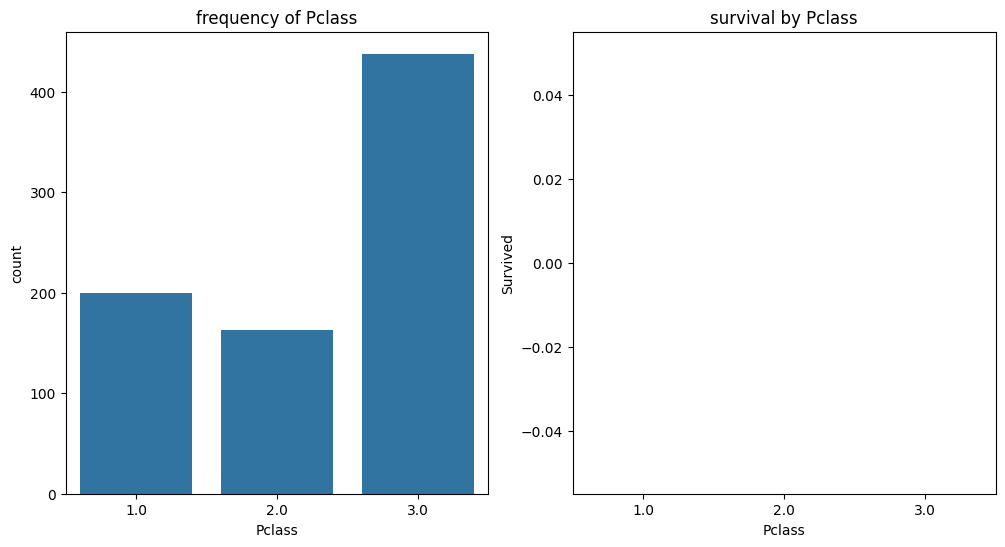

In [10]:
fig, axes=plt.subplots(1,2, figsize=(12, 6)) # matplotlib layout 1 row 2 columns, size 16*8
fig1_pclass=sns.countplot(data=TrainingData, x ="Pclass",    ax=axes[0]).set_title("frequency of Pclass")
fig2_pclass=sns.barplot(data=TrainingData, x= "Pclass",y= "Survived", ax=axes[1]).set_title("survival by Pclass")

### Age

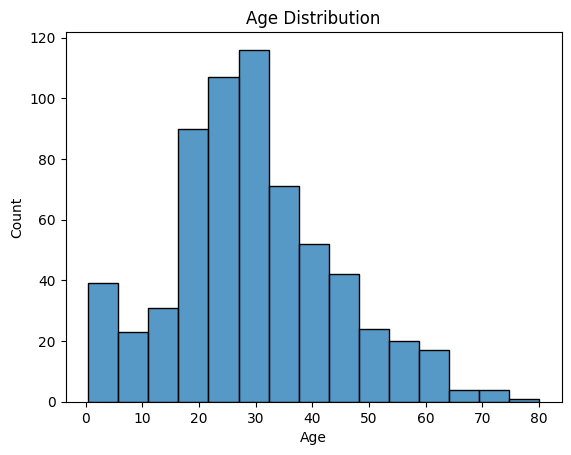

In [11]:
sns.histplot(data= TrainingData, x='Age',bins=15, kde=False    )    .set_title("Age Distribution")
plt.show()

## Encoding the Imputed or Transformed Data

Based on this quick analysis, we will propose the following transformations:

- `Age`: we need to handle the `Null` values, we impute with the mean even though there is better...
- `Embarked`: it has 2 missing values which we add to the most frequent value _S_
- `Fare`: same treatment as `Age`, we impute with the mean
- `hasCabin`: Since the number of `Null` values is significant, we will add a variable 1 or 0 to only retain whether the person had a cabin or not

In [12]:
# Here is our training data
TrainingData.head()

,Unnamed: 0,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,417,418.0,2.0,"Silven, Miss. Lyyli Karoliina",female,18.0,0.0,2.0,250652,13.0000,NaN,S,NaN
1,490,491.0,3.0,"Hagland, Mr. Konrad Mathias Reiersen",male,NaN,1.0,0.0,65304,19.9667,NaN,S,NaN
2,17,18.0,2.0,"Williams, Mr. Charles Eugene",male,NaN,0.0,0.0,244373,13.0000,NaN,S,NaN
3,771,772.0,3.0,"Jensen, Mr. Niels Peder",male,48.0,0.0,0.0,350047,7.8542,NaN,S,NaN
4,316,317.0,2.0,"Kantor, Mrs. Sinai (Miriam Sternin)",female,24.0,1.0,0.0,244367,26.0000,NaN,S,NaN


In [13]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

numeric_features=["Age", "Fare"]
categorical_features=["Embarked", "Sex"]

numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),
("scaler", MinMaxScaler()),])

categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),("onehot", OneHotEncoder()),])


preprocessor = ColumnTransformer(
transformers=[
("Preprocessing numerical", numeric_transformer, numeric_features),
(
"Preprocessing categorical",
categorical_transformer,
categorical_features,
),
        ]
    )

In [14]:
pipe = Pipeline(
        [
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(n_estimators=20)),
        ]
    )
pipe

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Preprocessing numerical', ...), ('Preprocessing categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


We _split_ our training _dataset_ to do cross-validation: part for learning and part for checking the score.

Let's arbitrarily take 10% of the dataset as test and 90% for training.

In [15]:
y = TrainingData["Survived"]
X = TrainingData.drop("Survived", axis = 'columns')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)
pd.concat([X_train, y_train]).to_csv("train.csv")
pd.concat([X_test, y_test]).to_csv("test.csv")

In [16]:
jetonapi = "$trotskitueleski1917"

# Random Forest

Random forests are algorithms that are often effective for classifications.

The idea is simple:
* We take a portion of the data and a portion of the variables at random from the dataset.
* We make a decision tree on this randomly drawn data, the decision tree being an algorithm that allows us to determine the variable and its value that best separates the population with respect to our target variable. The goal is to go down to the purest leaves.

![decision_tree.png](decision_tree.png)

* Then we repeat with another subset of the data and variables, which gives us a second tree...
* So, multiple random trees makes us... a random forest.
* An individual to predict will pass through each of the trees and will have a prediction for each tree. The final prediction is the weighted combination of each of our trees.

In [17]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
import pathlib
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier

In [18]:
pipe.fit(X_train, y_train)

ValueError: Input y contains NaN.

In [ ]:
# Calculate the score on the training dataset and on the test dataset (10% of the training dataset set aside)
# The score being the number of correct predictions
rdmf_score = pipe.score(X_test, y_test)
rdmf_score_tr = pipe.score(X_train, y_train)
print(f"{rdmf_score:.1%} correct answers on the test data for validation")
from sklearn.metrics import confusion_matrix
print(20*"-")
print("confusion matrix")
print(confusion_matrix(y_test, pipe.predict(X_test)))